In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score,silhouette_samples
import time

In [2]:
# Generate synthetic data (5 clusters)
X, _ = make_blobs(n_samples=600, centers=5, cluster_std=1.0, random_state=42)

In [3]:
# cluster_std is standard deviation of clusters

In [4]:
cluster_range = [i for i in range(2,6)]
cluster_range 

[2, 3, 4, 5]

#### Silhouette score method for chosing n clusters

#### code referred from 
"https://scikit-learn.org/1.5/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py"

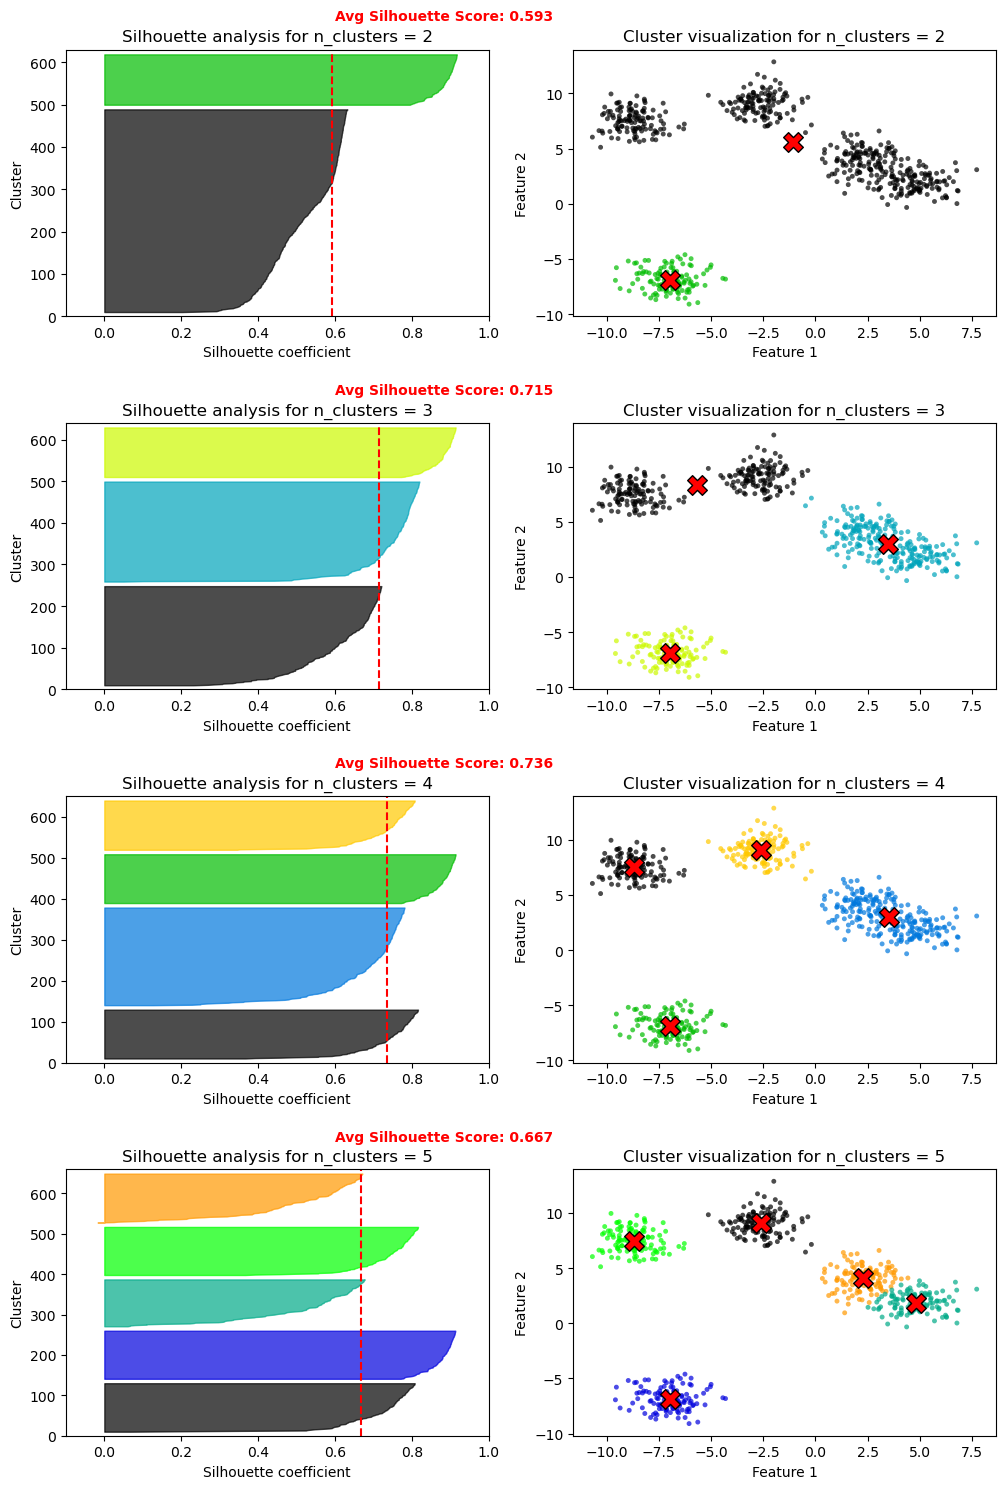

In [7]:
fig, axes = plt.subplots(len(cluster_range), 2, figsize=(12, 18))
fig.subplots_adjust(hspace=0.4)
for i, n_clusters in enumerate(cluster_range):
    # Apply K-Means
    kmeans = KMeans(n_clusters=n_clusters, init="k-means++", n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X)

    # Silhouette score
    silhouette_avg = silhouette_score(X, cluster_labels)
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    # Plot silhouette diagram
    ax1 = axes[i, 0]
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    
    y_lower = 10
    for j in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == j]
        ith_cluster_silhouette_values.sort()

        size_cluster_j = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_j

        color = cm.nipy_spectral(float(j) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        y_lower = y_upper + 10
    
    ax1.set_title(f"Silhouette analysis for n_clusters = {n_clusters}")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_ylabel("Cluster")
    ax1.text(0.6, y_upper + 80, f"Avg Silhouette Score: {silhouette_avg:.3f}", 
             fontsize=10, color="red", fontweight="bold")

    # Plot cluster visualization
    ax2 = axes[i, 1]
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=50, lw=0, alpha=0.7, c=colors, edgecolor='k')
    centers = kmeans.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker="X", c="red", s=200, edgecolor="black")

    ax2.set_title(f"Cluster visualization for n_clusters = {n_clusters}")
    ax2.set_xlabel("Feature 1")
    ax2.set_ylabel("Feature 2")

plt.show()

##### even though the score for clusters (3,4) is higher I would like to go with 5 clusters
becoz Wider and consistently shaped clusters indicate a well-defined grouping than a great silhouette score
##### n_clusters=5

In [9]:
start = time.time()
# Apply K-Means with Random Initialization
kmeans_random = KMeans(n_clusters=5, init="random", n_init=10, random_state=42)
kmeans_random.fit(X)
end = time.time()
rand_time = end-start
rand_time

0.0279238224029541

In [10]:
start = time.time()
# Apply K-Means with K-Means++
kmeans_plus = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
kmeans_plus.fit(X)
end = time.time()
plus_time = end-start
plus_time

0.027923107147216797

#### Observation of time took for K-means++ and random initialization

time took with K-means++ : 0.03 # ignore the units
time took with random : 0.25

We can see K-means took almost 7x times to complete the same convergence process with random initialization (changed in re-run)

#### What is n_init in K-Means?
In Scikit-learn’s K-Means, n_init refers to the number of times the algorithm runs with different centroid initializations, and the best result (lowest inertia) is chosen.


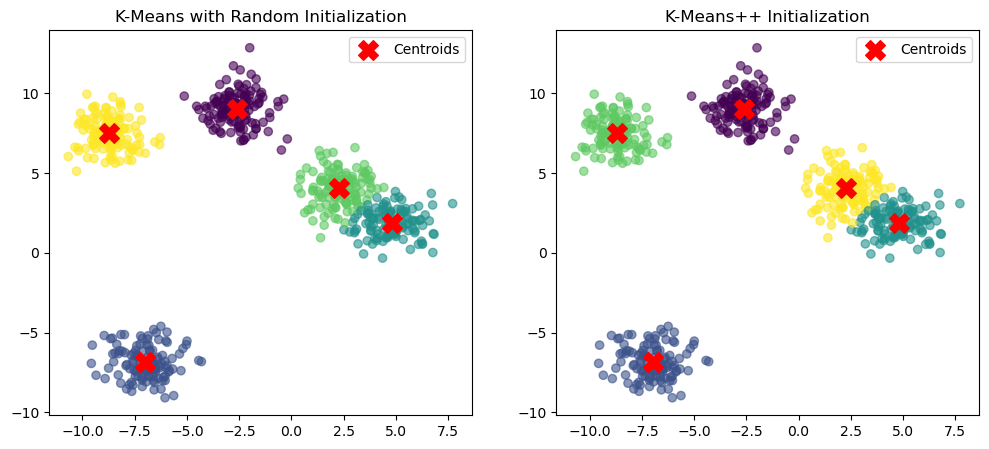

In [14]:
# Plot results
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Random Initialization
axs[0].scatter(X[:, 0], X[:, 1], c=kmeans_random.labels_, cmap="viridis", alpha=0.6)
axs[0].scatter(kmeans_random.cluster_centers_[:, 0], kmeans_random.cluster_centers_[:, 1], 
               c='red', marker='X', s=200, label="Centroids")
axs[0].set_title("K-Means with Random Initialization")
axs[0].legend()

# K-Means++
axs[1].scatter(X[:, 0], X[:, 1], c=kmeans_plus.labels_, cmap="viridis", alpha=0.6)
axs[1].scatter(kmeans_plus.cluster_centers_[:, 0], kmeans_plus.cluster_centers_[:, 1], 
               c='red', marker='X', s=200, label="Centroids")
axs[1].set_title("K-Means++ Initialization")
axs[1].legend()

plt.show()

#### Inertia 
(sum of squared distances to centroids) is often lower with higher n_init, meaning better clustering.

In [16]:
kmeans_random.inertia_

1117.9037136398156

In [17]:
kmeans_plus.inertia_

1117.9037136398156

Inertia is same with both

### Silhouette scores

In [20]:
rand_labels =  kmeans_random.predict(X)

In [21]:
kmp_labels = kmeans_plus.predict(X)

In [22]:
sil_score_rand = silhouette_score(X, rand_labels)
sil_score_plus = silhouette_score(X, kmp_labels)
sil_score_rand, sil_score_plus

(0.6667359725030233, 0.6667359725030233)

#### scores for individual clusters

In [24]:
silhouette_vals_rand = silhouette_samples(X, rand_labels)
silhouette_vals_plus = silhouette_samples(X, kmp_labels)

In [25]:
cluster_0_silhouette_rand = silhouette_vals_rand[rand_labels == 0]
np.mean(cluster_0_silhouette_rand)

0.7080271802155889

In [26]:
cluster_0_silhouette_plus = silhouette_vals_plus[kmp_labels == 0]
np.mean(cluster_0_silhouette_plus)

0.7080271802155889